In [3]:
from ase.io import read, write
from ase import units
from ase.visualize import view
import numpy as np
from imolcraft.crafter.ffxml import merge_xml
from imolcraft.trainer import DistanceTrainer
from imolcraft.calculator.distance import DistanceCalculator
from imolcraft.trainer.loss import loss_energy
from functools import partial

Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [4]:
atoms_snli = read("SNLi.log")

In [5]:
merge_xml(["SN.xml", "Li.xml"], "merged.xml")

'xmlfiles/merged.xml'

In [6]:
view(atoms_snli)

<Popen: returncode: None args: ['/Users/srak/miniconda3/envs/imc/bin/python'...>

In [7]:
calculator = DistanceCalculator(
    atoms_snli,
    1,
    "cn__Li",
    scan_idx=[[5,10]],
    directory="distance_scan",
    qmparams={
             "method": "wb97xd",
             "basis": "6-31g(d)",
             "opt": "modredundant",
             }
)

In [8]:
# calculator.do_qmscan()# 

In [9]:
import glob

g16logs = glob.glob("distance_scan/*.log")

In [10]:
for i, g16log in enumerate(g16logs):
    atoms = read(g16log)
    distance = atoms.get_distance(5, 10)
    energy = atoms.get_potential_energy()/(units.kJ / units.mol)
    calculator.qm_scan[0]["distance_A"].append(distance)
    calculator.qm_scan[0]["energy_kjmol"].append(energy)
    calculator.qm_scan[0]["atoms"].append(atoms)

In [11]:
# calculator.qm_scan[0]でcalculator.qm_scan[0]["distance_A"]ベースでソート
# "distance_A"の値で全リストをソート
order = np.argsort(calculator.qm_scan[0]["distance_A"])
for key in calculator.qm_scan[0]:
	calculator.qm_scan[0][key] = [calculator.qm_scan[0][key][i] for i in order]

In [12]:
calculator.do_ffscan("xmlfiles/merged.xml")

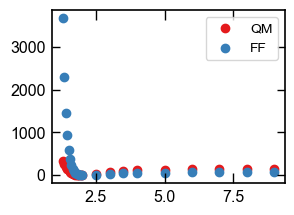

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.scatter(calculator.qm_scan[0]["distance_A"], np.array(calculator.qm_scan[0]["energy_kjmol"])-np.array(calculator.qm_scan[0]["energy_kjmol"]).min(), label="QM")

plt.scatter(calculator.ff_scan[0]["distance_A"], np.array(calculator.ff_scan[0]["energy_kjmol"])-np.array(calculator.ff_scan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()

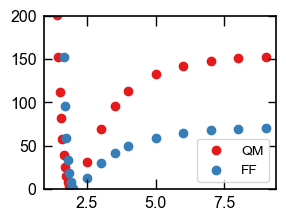

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.ylim(0,200)
plt.scatter(calculator.qm_scan[0]["distance_A"], np.array(calculator.qm_scan[0]["energy_kjmol"])-np.array(calculator.qm_scan[0]["energy_kjmol"]).min(), label="QM")

plt.scatter(calculator.ff_scan[0]["distance_A"], np.array(calculator.ff_scan[0]["energy_kjmol"])-np.array(calculator.ff_scan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()

In [15]:
len(calculator.qm_scan[0]["energy_kjmol"])

24

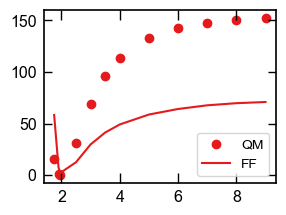

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# plt.ylim(0,400)
dihed_idx = [9, 12, 13, 15, 16,17,18,19,20,21,22,23]
plt.scatter(np.array(calculator.qm_scan[0]["distance_A"])[dihed_idx], 
            np.array(calculator.qm_scan[0]["energy_kjmol"])[dihed_idx]-np.array(calculator.qm_scan[0]["energy_kjmol"]).min(), label="QM")

plt.plot(np.array(calculator.ff_scan[0]["distance_A"])[dihed_idx], 
            np.array(calculator.ff_scan[0]["energy_kjmol"])[dihed_idx]-np.array(calculator.ff_scan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()

In [26]:
calculator.qm_scan[0]["energy_kjmol"] = np.array(calculator.qm_scan[0]["energy_kjmol"])[dihed_idx]
calculator.qm_scan[0]["distance_A"] = np.array(calculator.qm_scan[0]["distance_A"])[dihed_idx]
calculator.qm_scan[0]["atoms"] = [calculator.qm_scan[0]["atoms"][i] for i in dihed_idx]

calculator.ff_scan[0]["energy_kjmol"] = np.array(calculator.ff_scan[0]["energy_kjmol"])[dihed_idx]
calculator.ff_scan[0]["distance_A"] = np.array(calculator.ff_scan[0]["distance_A"])[dihed_idx]
calculator.ff_scan[0]["atoms"] = [calculator.ff_scan[0]["atoms"][i] for i in dihed_idx]

In [27]:
lossfn = partial(loss_energy, 
                 weight_scheme="uniform", 
                 zeropoint="qmmin")

In [28]:
# from imolcraft.crafter.asemol import aseatoms2pdb

# aseatoms2pdb("hoge.pdb", calculator.ff_scan[0]["atoms"][0])

In [65]:
dtrainer = DistanceTrainer(ffxml_list=["SN.xml", "Li.xml"], 
                           nums_ffxml=[1,1], 
                           pdbfile="testtest.pdb", 
                           calculator=calculator,
                           loss_fn=lossfn,
                        #    charge_params={"nc": 0.8, "target_lists": [[0,1,2,3,4,5,6,7,8,9]], "target_charges": [0.0]}, 
                           opt_fftypes=["NonbondedForce/charges", "NonbondedForce/sigma"],
                           # sigma_params={"target_list": [4]},
                           lr=0.005)

In [66]:
dtrainer.ffparams

{'HarmonicBondForce': {'length': Array([0.1153, 0.1467, 0.1538, 0.1097], dtype=float64),
  'k': Array([746040.672, 247575.648, 194572.736, 314569.856], dtype=float64)},
 'HarmonicAngleForce': {'angle': Array([3.11680898, 1.94970731, 1.90956473, 1.91637152, 1.87762521],      dtype=float64),
  'k': Array([612.671488, 554.597568, 409.019472, 391.756288, 326.01728 ],      dtype=float64)},
 'PeriodicTorsionForce': {'proper_phase': Array([3.14159265, 3.14159265, 0.        , 0.        , 0.        ],      dtype=float64),
  'proper_k': Array([0.        , 0.        , 0.65084444, 0.65084444, 0.50208   ],      dtype=float64),
  'improper_phase': Array([], shape=(0,), dtype=float64),
  'improper_k': Array([], shape=(0,), dtype=float64)},
 'NonbondedForce': {'sigma': Array([0.32735182, 0.34789595, 0.33977095, 0.2600177 , 0.20259037],      dtype=float64),
  'epsilon': Array([0.4594032, 0.6677664, 0.4510352, 0.0870272, 0.0765672], dtype=float64),
  'charge': Array([-0.4450872,  0.2965618, -0.0415062, 

In [67]:
from imolcraft.trainer.dmff_utils import neutralize

def grad_modify(grads):
    grads["NonbondedForce"]["charge"] = grads["NonbondedForce"]["charge"].at[10].set(0.0)
    return grads

def ffparams_modify(ffparams):
    ffparams = neutralize(ffparams, dtrainer.natoms_list, target_lists=[[0,1,2,3,4,5,6,7,8,9]], target_charges=[0.0])

    return ffparams

In [68]:
dtrainer.add_modifyfn("after_grad", grad_modify)
dtrainer.add_modifyfn("after_update", ffparams_modify)

In [69]:
dtrainer.setup()

In [64]:
dtrainer.fit(steps=300, checkpoint_frequency=10)

grad obtained.... Memory Usage: 1005.14 MB
grad modify.... Memory Usage: 1005.14 MB
update finished.... Memory Usage: 1005.14 MB
Epoch 0, Loss: 1.067014714089031, Memory Usage: 1005.14 MB
Loss:  1.067014714089031
Best Loss:  1.067014714089031 at epoch  0
Epoch 0 completed in 0.26 seconds.
----
grad obtained.... Memory Usage: 1005.14 MB
grad modify.... Memory Usage: 1005.14 MB
update finished.... Memory Usage: 1005.14 MB
Loss:  4.599835869754038
Best Loss:  1.067014714089031 at epoch  0
Epoch 1 completed in 0.01 seconds.
----
grad obtained.... Memory Usage: 1005.14 MB
grad modify.... Memory Usage: 1005.14 MB
update finished.... Memory Usage: 1005.14 MB
Loss:  4.523814313598184
Best Loss:  1.067014714089031 at epoch  0
Epoch 2 completed in 0.01 seconds.
----
grad obtained.... Memory Usage: 1005.14 MB
grad modify.... Memory Usage: 1005.14 MB
update finished.... Memory Usage: 1005.14 MB
Loss:  4.450812626261158
Best Loss:  1.067014714089031 at epoch  0
Epoch 3 completed in 0.01 seconds.
--

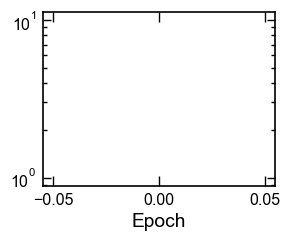

In [70]:
plt.yscale("log")
plt.xlabel("Epoch")
plt.plot(dtrainer.epochs, dtrainer.losses)

In [71]:
calculator.do_ffscan("SN1_Li1_best.xml")

In [72]:
np.array(calculator.qm_scan[0]["energy_kjmol"]).argmin()

2

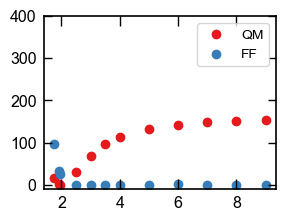

In [74]:
import numpy as np
import matplotlib.pyplot as plt

plt.ylim(-10,400)
plt.scatter(calculator.qm_scan[0]["distance_A"], np.array(calculator.qm_scan[0]["energy_kjmol"])-np.array(calculator.qm_scan[0]["energy_kjmol"]).min(), label="QM")

plt.scatter(calculator.ff_scan[0]["distance_A"], np.array(calculator.ff_scan[0]["energy_kjmol"])-np.array(calculator.ff_scan[0]["energy_kjmol"]).min(), label="FF")

plt.legend()